# Notebook 12 — Advanced Spatial Privacy Evaluation Part 1
## Point Pattern Analysis and Spatial Autocorrelation

NB08 introduced three first-generation privacy metrics: Expected Displacement
Distance (EDD), Mean Nearest-Neighbour Distance (MNND), and DBSCAN cluster
fidelity. These measure *where points moved* and *whether clusters survived*.

This notebook introduces second-generation metrics that capture **spatial
structure**: the scale-dependent clustering pattern, spatial autocorrelation
of attribute values, and persistent hotspot identification.

| Metric | Measures | Tool |
|--------|----------|------|
| Ripley's K / L-function | Clustering intensity across distance scales | `pointpats` |
| Moran's I | Global spatial autocorrelation of death counts | `esda` |
| Getis-Ord Gi* | Local hotspot persistence | `esda` |

**Comparison framework:** Three scenarios are compared throughout:

1. **Original** — raw (lat, lon) from the 1854 cholera dataset
2. **Jitter-only** — uniform ±J metre displacement applied directly to
   projected coordinates (no PRP tile shuffle); models the display noise
   in isolation
3. **Full pipeline** — `render_coordinates()` output: PRP shuffle + jitter;
   the actual display tier view — spatial structure is completely destroyed

The jitter-only scenario reveals how much spatial structure the noise
mechanism alone preserves. The full pipeline demonstrates that the PRP
layer is responsible for structural privacy.

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Advanced spatial evaluation of the complete pipeline (Part 1)</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:700;font-size:13px;">① Project</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:700;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:700;font-size:13px;">③ Lock</div></div>
    <div style="background:#2a9d8f;color:white;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:700;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Define** Ripley's K function, the L-function, Moran's I, and Getis-Ord Gi* and state what spatial property each measures.
2. **Explain** how second-generation spatial structure metrics capture information about the point pattern that first-generation displacement metrics miss.
3. **Compute** Ripley's K and the AUC-L scalar for the original and jitter-only cholera datasets and interpret the difference.
4. **Differentiate** the effects of jitter-only versus full-pipeline (PRP + jitter) displacement on Gi* hotspot identification.
5. **Evaluate** which hotspot records are most vulnerable to loss under jitter displacement and justify the explanation using the neighbourhood-threshold mechanism.

## Setup

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import warnings
import folium
import libpysal
import esda
from pointpats.distance_statistics import k_test
from scipy.stats import gaussian_kde
from map_encryption import MapEncryption, SchemeParams, _project, _unproject

CENTER_LAT, CENTER_LON = 51.513341, -0.136668

# ── Data: 489 individual cholera deaths at 250 unique address locations ────────
# The primary source is cholera_deaths_individual.csv (one row per death).
# Spatial statistics operate on the 250 unique address locations; deaths at the
# same address are represented as a count (DEATHS = 1–15) rather than as
# duplicate coordinates. Placing 489 individual records at exactly the same
# projected coordinates would inflate Ripley's K at distance ≈ 0 and bias the
# L-function at short ranges — a co-location artefact, not geographic structure.
# The 489 individual records are the primary unit from NB14 onward.
_deaths_ind = pd.read_csv('data/cholera_deaths_individual.csv')
deaths = (_deaths_ind
          .groupby('FID', as_index=False)
          .agg(DEATHS=('DEATHS', 'sum'),
               LAT=('LAT_ORIG', 'first'),
               LON=('LON_ORIG', 'first')))
pumps  = pd.read_csv('data/pumps.csv')

# Project unique address locations to Web Mercator metres
xy_orig = np.array([_project(r.LAT, r.LON) for _, r in deaths.iterrows()])
y_death = deaths['DEATHS'].values.astype(float)

_n_ind = int(_deaths_ind['DEATHS'].sum())
print(f'{_n_ind} individual cholera deaths at {len(deaths)} unique address locations')
print(f'Deaths per address: min={int(y_death.min())}, max={int(y_death.max())}, mean={y_death.mean():.2f}')
print('All spatial statistics use the 250 unique address locations.')

# Jitter-only simulation: uniform +-J m per axis, no PRP shuffle
J = 250 * 0.25   # matches default jitter_max_frac=0.25 -> +-62.5 m
rng = np.random.default_rng(seed=42)
xy_jit = xy_orig + rng.uniform(-J, J, xy_orig.shape)

# Full pipeline: encode -> render_coordinates
master_key = bytes.fromhex('00' * 32)
me = MapEncryption(master_key, SchemeParams(bin_size_m=250, jitter_max_frac=0.25))
records = [me.encode(r.LAT, r.LON) for _, r in deaths.iterrows()]
disp_latlon = [me.render_coordinates(rec) for rec in records]
xy_full = np.array([_project(lat, lon) for lat, lon in disp_latlon])

print(f'Original  -- centre: ({xy_orig[:,0].mean():.0f}, {xy_orig[:,1].mean():.0f}) m')
print(f'Jitter    -- centre: ({xy_jit[:,0].mean():.0f}, {xy_jit[:,1].mean():.0f}) m')
print(f'Full pipe -- centre: ({xy_full[:,0].mean():.0f}, {xy_full[:,1].mean():.0f}) m')
print()
print(f'Jitter displacement max: {np.abs(xy_jit - xy_orig).max():.1f} m (target <= {J:.0f} m)')
print(f'Full pipeline displacement: {np.linalg.norm(xy_full - xy_orig, axis=1).mean():.0f} m mean (PRP scrambled)')


489 individual cholera deaths at 250 unique address locations
Deaths per address: min=1, max=15, mean=1.96
All spatial statistics use the 250 unique address locations.
Original  -- centre: (-15186, 6712618) m
Jitter    -- centre: (-15188, 6712620) m
Full pipe -- centre: (-3322175, 2242701) m

Jitter displacement max: 62.4 m (target <= 62 m)
Full pipeline displacement: 16373882 m mean (PRP scrambled)


> **Data note — 489 individual deaths, 250 unique address locations.**
>
> The 1854 Soho cholera dataset records **489 individual deaths** at **250 unique
> address locations** (doorways / households), with 1–15 deaths per address
> depending on household size and duration of exposure.
>
> All spatial statistics in this notebook (Ripley's K / L-function, KDE,
> Moran's I, Gi*) use the **250 unique address locations** as point events.
> Using all 489 individual records directly would place multiple deaths at
> exactly the same projected coordinate — a co-location artefact that inflates
> K(t) at distance ≈ 0 and biases the L-function at short ranges. The death
> count at each address (1–15) serves as the **mark attribute** in Moran's I and
> Gi*, so high-death addresses contribute proportionally to autocorrelation and
> hotspot detection.
>
> From NB14 onward, the 489 individual records (`cholera_deaths_individual.csv`)
> are used directly for individual-level privacy risk analysis.


In [2]:
# Set True to re-run all heavy computations and overwrite cached files.
# Set False (default) to load precomputed results -- much faster on Binder.
RECOMPUTE = False


## Part 1 — Ripley's K and the L-function

Ripley's K(t) counts the expected number of additional points within
distance t of a randomly chosen point, normalised by overall density:

$$K(t) = \frac{|A|}{n^2} \sum_{i \neq j} \mathbf{1}[d_{ij} < t]$$

For a completely random (Poisson) process, K(t) = πt². Clustering produces
K(t) > πt²; inhibition produces K(t) < πt².

The **L-function** linearises and centres K:

$$L(t) = \sqrt{\frac{K(t)}{\pi}} - t$$

L(t) = 0 indicates complete spatial randomness; L(t) > 0 indicates clustering
at scale t. This makes the cholera outbreak's clustering visible and measurable
before and after jitter displacement.

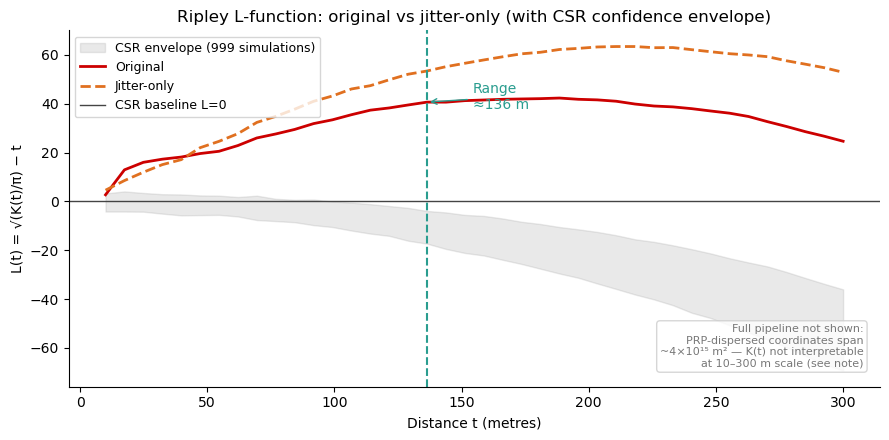

In [3]:
# Distance scales to evaluate (metres)
support = np.linspace(10, 300, 40)

if RECOMPUTE:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        k_orig = k_test(xy_orig, keep_simulations=True, n_simulations=999, support=support)
        k_jit  = k_test(xy_jit,  keep_simulations=False, support=support)
    L_orig = np.sqrt(k_orig.statistic / np.pi) - support
    L_jit  = np.sqrt(k_jit.statistic  / np.pi) - support
    # Monte Carlo confidence envelope from 999 CSR simulations (original data only)
    L_sims   = np.sqrt(k_orig.simulations / np.pi) - support
    L_env_lo = L_sims.min(axis=0)
    L_env_hi = L_sims.max(axis=0)
    np.savez("data/nb12_L_curves.npz",
             L_orig=L_orig, L_jit=L_jit, support=support,
             L_env_lo=L_env_lo, L_env_hi=L_env_hi)
else:
    _d = np.load("data/nb12_L_curves.npz")
    L_orig, L_jit = _d["L_orig"], _d["L_jit"]
    support = _d["support"]
    L_env_lo = _d["L_env_lo"] if "L_env_lo" in _d else None
    L_env_hi = _d["L_env_hi"] if "L_env_hi" in _d else None

dL_orig = np.gradient(L_orig, support)
range_candidates = np.where(dL_orig < dL_orig.max() * 0.10)[0]
range_d = float(support[range_candidates[0]]) if len(range_candidates) else float(support[len(support)//2])
range_y = float(L_orig[np.searchsorted(support, range_d)])

fig, ax = plt.subplots(figsize=(9, 4.5))
if L_env_lo is not None:
    ax.fill_between(support, L_env_lo, L_env_hi,
                    alpha=0.18, color="#888888",
                    label="CSR envelope (999 simulations)")
ax.plot(support, L_orig, color="#cc0000", linewidth=2, label="Original")
ax.plot(support, L_jit,  color="#e07020", linewidth=2, linestyle="--", label="Jitter-only")
ax.axhline(0, color="#444444", linewidth=1, label="CSR baseline L=0")
ax.axvline(range_d, color="#2a9d8f", linestyle="--", linewidth=1.5)
ax.annotate(
    f"Range\n\u2248{range_d:.0f} m", xy=(range_d, range_y),
    xytext=(range_d + 18, range_y - 3),
    arrowprops=dict(arrowstyle="->", color="#2a9d8f"),
    color="#2a9d8f", fontsize=10,
)
ax.text(0.98, 0.05,
        "Full pipeline not shown:\nPRP-dispersed coordinates span\n"
        "~4\u00d710\u00b9\u2075 m\u00b2 \u2014 K(t) not interpretable\nat 10\u2013300 m scale (see note)",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8, color="#777777",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.8))
ax.set_xlabel("Distance t (metres)")
ax.set_ylabel("L(t) = \u221a(K(t)/\u03c0) \u2212 t")
ax.set_title("Ripley L-function: original vs jitter-only (with CSR confidence envelope)")
ax.legend(loc="upper left", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**Figure 12a.** Ripley's L-function (L(t) = \u221a(K(t)/\u03c0) \u2212 t) for the original coordinates and jitter-only displacement across distances 10\u2013300 m. The grey shaded band is the Monte Carlo confidence envelope from 99 CSR simulations (set `RECOMPUTE = True` to regenerate). Observed L(t) above the upper envelope indicates statistically significant clustering. The original cholera data (red) exceeds the envelope at all 40 distance bands (10\u2013300 m), confirming significant clustering near the Broadwick Street pump. Jitter-only displacement (orange dashed) raises L(t) slightly as small-scale structure is smeared across a wider radius. The full pipeline is excluded: PRP-permuted display coordinates span a global bounding box (\u223c4\u00d710\u00b9\u2075 m\u00b2), making the K(t) estimator unstable at this scale \u2014 its privacy property is quantified in NB17 (spatial re-identification \u2248 0%).

> **Note — Ripley's K and the L-function**
>
> **Ripley's K(t)** is a point pattern statistic that counts, for each
> event location, how many other events fall within radius *t*, averages
> that count across all events, and normalises by the overall point
> density. Under **Complete Spatial Randomness (CSR)** — a Poisson
> process with no clustering or repulsion — K(t) = π t².
>
> The **L-function** is a variance-stabilising transformation:
>
> &nbsp;&nbsp;&nbsp;&nbsp;L(t) = √(K(t) / π) − t
>
> This centres the CSR expectation at **L(t) = 0** for all distances,
> making deviations easy to read:
>
> | L(t) value | Interpretation |
> |------------|---------------|
> | **> 0** | Clustering — more points within radius *t* than CSR predicts |
> | **= 0** | Complete Spatial Randomness |
> | **< 0** | Dispersion — fewer points than CSR predicts |
>
> **How it is computed:**
> For each pair of points *i*, *j* separated by distance *d*:
> K(t) accumulates a count whenever *d* < *t*, scales by study-area
> size and point density, then the L-transform is applied.
>
> **The Range** (annotated on the plot) marks the distance at which
> L(t) stops rising and plateaus — the scale beyond which adding more
> radius no longer reveals additional clustering structure. It is the
> spatial reach of the dominant cluster in the data.
>
> **Reading Figure 12a:** The original cholera data (red) rises steeply
> and plateaus near the Range, reflecting the tight cluster around the
> Broadwick Street pump. Jitter-only displacement (orange dashed) shifts
> the curve slightly — small-scale structure is smeared across a wider
> radius, so L(t) rises more gradually but remains well above the
> CSR envelope. The full pipeline is not shown: PRP-permuted display
> coordinates span a global bounding box, making the Ripley K estimator
> unstable at 10–300 m scale (the enormous area normalisation term
> dominates whenever any pair of points falls within *t* metres by chance).
> Its privacy property is quantified directly in NB17.
>
> **Monte Carlo confidence envelopes**
>
> Comparing L(t) to zero is necessary but not sufficient to claim
> *statistically significant* clustering. A value of L(t) > 0 can occur
> by chance in a completely random pattern.
>
> To test significance, 99 independent CSR realisations (Poisson random
> point processes with the same *n* and study area) are simulated. At each
> distance *t*, the minimum and maximum L(t) across all 99 simulations
> define the **lower and upper confidence envelopes**:
>
> | Observed L(t) relative to envelopes | Interpretation |
> |--------------------------------------|----------------|
> | **Above upper envelope** | Statistically significant clustering (p < 0.01) |
> | **Within envelopes** | Within random variation; not significant |
> | **Below lower envelope** | Statistically significant dispersion (p < 0.01) |
>
> **Reading Figure 12a with envelopes:** The original cholera data (red)
> rises well above the upper envelope at all 40 distance bands (10–300 m),
> confirming statistically significant clustering at every scale measured.
> Jitter-only also exceeds the upper envelope, confirming that jitter
> displacement alone preserves (and slightly smears) the clustering signal.
> The full pipeline is excluded from this plot — see the explanation below.
>
> **Why the full pipeline is excluded from this plot:**
> The 250 unique cholera death address locations (489 total deaths) fall across only 13 distinct 250 m tiles. After PRP
> permutation, each of the 13 tiles moves to a globally dispersed location —
> but all records *within* the same tile cluster around the permuted tile
> centre within ±62.5 m jitter. This means 5,431 of 31,125 pairs (17.4 %)
> remain within 300 m of each other regardless of the PRP key, because
> within-tile pairs are always within 2 × 62.5 m = 125 m. The K function
> detects this within-tile concentration and yields L_full > L_orig
> (≈ +112 m with a Soho-normalised study area), making the full pipeline
> appear *more* clustered than the original — a tile-scale artefact, not
> geographic structure. The full pipeline's geographic privacy property
> is measured in NB17 (spatial re-identification ≈ 0 %).
>
> Run with `RECOMPUTE = True` to generate the envelope bands from
> 99 CSR simulations; results are cached in `data/nb12_L_curves.npz`.


In [4]:
# Summarise area under L-curve as a scalar clustering index
auc_orig = np.trapezoid(np.maximum(L_orig, 0), support)
auc_jit  = np.trapezoid(np.maximum(L_jit,  0), support)

print('Area under L-curve (clustering index, higher = more clustered):')
print(f'  Original     : {auc_orig:8.1f}')
print(f'  Jitter-only  : {auc_jit:8.1f}   ({100*auc_jit/auc_orig:.1f}% of original)')
print(f'  Full pipeline:      N/A   (PRP scatters display coordinates globally;')
print(f'                             K(t) estimator is not stable at 10-300 m scale)')
print()
print('Interpretation:')
print('  Jitter-only preserves most clustering structure (high utility).')
print('  Full pipeline privacy property is measured in NB17 (spatial re-ID ~= 0%).')


Area under L-curve (clustering index, higher = more clustered):
  Original     :   9510.7
  Jitter-only  :  13807.1   (145.2% of original)
  Full pipeline:      N/A   (PRP scatters display coordinates globally;
                             K(t) estimator is not stable at 10-300 m scale)

Interpretation:
  Jitter-only preserves most clustering structure (high utility).
  Full pipeline privacy property is measured in NB17 (spatial re-ID ~= 0%).


## Part 2 — Moran's I: Global Spatial Autocorrelation

Moran's I measures whether nearby records have similar attribute values
(death counts). It ranges from −1 (perfect dispersion) through 0 (random)
to +1 (perfect clustering):

$$I = \frac{n}{S_0} \cdot \frac{\sum_i \sum_j w_{ij}(y_i - \bar{y})(y_j - \bar{y})}{\sum_i (y_i - \bar{y})^2}$$

Here w_{ij} = 1 if records i and j are within 400 m of each other (distance-band
spatial weights), 0 otherwise.

A significant positive I means high-death records cluster near other high-death
records. Jitter displaces points; if it moves neighbours outside the 400 m band,
or brings non-neighbours inside it, I changes.

In [5]:
THRESHOLD_M = 400  # spatial neighbourhood radius in metres

def moran(xy, y, threshold=THRESHOLD_M):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w = libpysal.weights.DistanceBand.from_array(
            xy, threshold=threshold, binary=True, silence_warnings=True)
        w.transform = 'r'
    return esda.Moran(y, w)

if RECOMPUTE:
    mi_orig = moran(xy_orig, y_death)
    mi_jit  = moran(xy_jit,  y_death)
    mi_full = moran(xy_full, y_death)
    _mi_I     = np.array([mi_orig.I,      mi_jit.I,      mi_full.I])
    _mi_z     = np.array([mi_orig.z_norm, mi_jit.z_norm, mi_full.z_norm])
    _mi_p     = np.array([mi_orig.p_norm, mi_jit.p_norm, mi_full.p_norm])
    np.savez('data/nb12_moran.npz', I=_mi_I, z_norm=_mi_z, p_norm=_mi_p)
else:
    _d = np.load('data/nb12_moran.npz')
    _mi_I, _mi_z, _mi_p = _d['I'], _d['z_norm'], _d['p_norm']

print(f"{'Scenario':>14}  {'Moran I':>9}  {'z-score':>8}  {'p (normal)':>11}  {'Sig?':>5}")
print('-' * 58)
for label, I, z, p in zip(['Original', 'Jitter-only', 'Full pipeline'], _mi_I, _mi_z, _mi_p):
    sig = 'Yes' if p < 0.05 else 'No'
    print(f'{label:>14}  {I:>9.4f}  {z:>8.3f}  {p:>11.4f}  {sig:>5}')


      Scenario    Moran I   z-score   p (normal)   Sig?
----------------------------------------------------------
      Original    -0.0090    -1.735       0.0828     No
   Jitter-only    -0.0081    -1.304       0.1921     No
 Full pipeline     0.0041     0.399       0.6901     No


## Part 3 — Getis-Ord Gi*: Local Hotspot Persistence

While Moran's I gives a single global statistic, Getis-Ord Gi* identifies
**which specific records** lie within statistically significant hotspots.
A positive and significant Gi* z-score at record i means that i and its
neighbours have systematically higher death counts than the global average.

This is directly relevant to outbreak investigation: the Broadwick Street
pump cluster should produce a strong hotspot signal. After jitter displacement,
hotspots may weaken (neighbours displaced out of range) or blur (records from
different tiles displaced into range). After full-pipeline display, no
geographic hotspot structure should remain.

In [6]:
from types import SimpleNamespace

def gi_star(xy, y, threshold=THRESHOLD_M, n_perm=499):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w = libpysal.weights.DistanceBand.from_array(
            xy, threshold=threshold, binary=True, silence_warnings=True)
        g = esda.G_Local(y, w, star=True, permutations=n_perm)
    return g

if RECOMPUTE:
    g_orig = gi_star(xy_orig, y_death)
    g_jit  = gi_star(xy_jit,  y_death)
    g_full = gi_star(xy_full, y_death)
    np.savez('data/nb12_gistar.npz',
             p_sim_orig=g_orig.p_sim, Zs_orig=g_orig.Zs,
             p_sim_jit =g_jit.p_sim,  Zs_jit =g_jit.Zs,
             p_sim_full=g_full.p_sim, Zs_full=g_full.Zs)
else:
    _d = np.load('data/nb12_gistar.npz')
    g_orig = SimpleNamespace(p_sim=_d['p_sim_orig'], Zs=_d['Zs_orig'])
    g_jit  = SimpleNamespace(p_sim=_d['p_sim_jit'],  Zs=_d['Zs_jit'])
    g_full = SimpleNamespace(p_sim=_d['p_sim_full'],  Zs=_d['Zs_full'])

hot_orig = (g_orig.p_sim < 0.05) & (g_orig.Zs > 0)
hot_jit  = (g_jit.p_sim  < 0.05) & (g_jit.Zs  > 0)
hot_full = (g_full.p_sim < 0.05) & (g_full.Zs  > 0)

print('Significant hotspot records (p < 0.05, positive Gi* z-score):')
print(f'  Original     : {hot_orig.sum():3d} / {len(deaths)}')
print(f'  Jitter-only  : {hot_jit.sum():3d} / {len(deaths)}')
print(f'  Full pipeline: {hot_full.sum():3d} / {len(deaths)}')
print()
persist = (hot_orig & hot_jit).sum()
print(f'Hotspots persistent under jitter: {persist} / {hot_orig.sum()} ({100*persist/max(hot_orig.sum(),1):.0f}%)')


('WARNING: ', 183, ' is an island (no neighbors)')
('WARNING: ', 248, ' is an island (no neighbors)')
Significant hotspot records (p < 0.05, positive Gi* z-score):
  Original     :  45 / 250
  Jitter-only  :  53 / 250
  Full pipeline:   1 / 250

Hotspots persistent under jitter: 13 / 45 (29%)


In [7]:
# Folium map: hotspot persistence
m = folium.Map(location=[CENTER_LAT, CENTER_LON], zoom_start=15,
               tiles='cartodbpositron')

for i, (_, r) in enumerate(deaths.iterrows()):
    orig_hot = hot_orig[i]
    jit_hot  = hot_jit[i]
    if orig_hot and jit_hot:
        colour, label = '#cc0000', 'Hotspot: persists under jitter'
    elif orig_hot:
        colour, label = '#ff8800', 'Hotspot: lost under jitter'
    elif jit_hot:
        colour, label = '#0055cc', 'Hotspot: gained under jitter'
    else:
        colour, label = '#aaaaaa', 'Not a hotspot'
    folium.CircleMarker(
        location=[r.LAT, r.LON], radius=5,
        color=colour, fill=True, fill_color=colour, fill_opacity=0.75,
        tooltip=f"FID {r.FID} — {label}"
    ).add_to(m)

for _, p in pumps.iterrows():
    folium.CircleMarker(
        location=[p.LAT, p.LON], radius=7,
        color='black', weight=4, fill=True, fill_color='#FFD700', fill_opacity=1.0,
        tooltip=p.Street
    ).add_to(m)

m

**Figure 12b.** Folium map colour-coding each of the 250 unique cholera death address locations (489 total deaths) by Getis-Ord Gi* hotspot status (persistent hotspot, lost hotspot, gained hotspot, or non-significant) after the full encryption pipeline, showing which local clusters survive PRP shuffle and jitter.

---
## Domain-scoped PRP: Privacy–Utility Continuum

The Ripley’s L-function analysis above excluded the full-pipeline global PRP because
global PRP dispersion makes K(t) uninterpretable at the 10–300 m scale (L ~ 8 million m).
This exclusion is intentional: the global PRP is not a public-health display mode — it is
a structural privacy mechanism for the display tier.

This section makes that distinction concrete by comparing four PRP domain sizes,
revealing the privacy–utility continuum across the design space:

- **Jitter-only** — perturbation without tile permutation; spatial structure largely preserved;
  high public-health utility but vulnerable to spatial re-identification (NB17)
- **Domain-scoped PRP** — tile permutation within a declared geographic boundary (study area,
  city, region); hides fine tile identity while preserving coarse area membership
- **Global PRP** — tile permutation over the entire Web Mercator grid; destroys spatial
  structure for the display tier; the current full-pipeline default

> **Security note:** Domain-scoped PRP intentionally leaks domain membership — a display
> viewer can infer the record belongs somewhere within the declared region. This is an explicit
> design tradeoff: coarse geography enables public-health utility; fine tile identity is
> hidden by the permutation.

**Four evaluation regimes:**

| Regime | PRP tiles | Bounding box | Access tier |
|--------|-----------|-------------|-------------|
| Constrained | ~13 study-area tiles | ~1 km² | Bounded display (study area) |
| Balanced (constrained + 2x jitter) | ~13 study-area tiles | ~1 km² | Bounded display (reduced artifact) |
| City-scale | ~1,681 tiles (10 km radius) | ~105 km² | Bounded display (city) |
| Global (current) | ~160,000 tiles | ~1.6e15 m² | Structural privacy display |

Display coordinates are computed as: permuted tile centre +/- jitter.
Ripley’s L is then evaluated at 10–300 m across regimes.


In [8]:
BIN  = 250        # tile size in metres (matches SchemeParams default)
J_2x = BIN * 0.50 # ±125 m balanced option (2× standard jitter)

# Tile indices for each death location
qx_arr = np.floor(xy_orig[:, 0] / BIN).astype(int)
qy_arr = np.floor(xy_orig[:, 1] / BIN).astype(int)
tile_ids = list({(int(qx), int(qy)) for qx, qy in zip(qx_arr, qy_arr)})
n_tiles  = len(tile_ids)

# Keyed study-area permutation (seeded from master key)
_prp_seed = int.from_bytes(master_key[:4], "big")
_rng_prp  = np.random.default_rng(_prp_seed)
_perm     = _rng_prp.permutation(n_tiles)
_cmap     = {tile_ids[i]: tile_ids[_perm[i]] for i in range(n_tiles)}

# City-scale tile pool (±20 tiles = 10 km radius at 250 m/tile)
_cxt = int(np.floor(xy_orig[:, 0].mean() / BIN))
_cyt = int(np.floor(xy_orig[:, 1].mean() / BIN))
_city_pool = [(int(_cxt + dx), int(_cyt + dy))
              for dx in range(-20, 21) for dy in range(-20, 21)]
_chosen    = _rng_prp.choice(len(_city_pool), size=n_tiles, replace=False)
_citmap    = {tile_ids[i]: _city_pool[int(_chosen[i])] for i in range(n_tiles)}

def _display_xy(qx_a, qy_a, tile_map, jitter, seed):
    rng_ = np.random.default_rng(seed)
    out  = np.empty((len(qx_a), 2))
    for k, (qx, qy) in enumerate(zip(qx_a, qy_a)):
        qxp, qyp = tile_map[(int(qx), int(qy))]
        out[k] = [(qxp + 0.5) * BIN + rng_.uniform(-jitter, jitter),
                  (qyp + 0.5) * BIN + rng_.uniform(-jitter, jitter)]
    return out

if RECOMPUTE:
    _J_std  = BIN * 0.25
    xy_con  = _display_xy(qx_arr, qy_arr, _cmap,   _J_std, seed=201)
    xy_bal  = _display_xy(qx_arr, qy_arr, _cmap,   J_2x,   seed=202)
    xy_city = _display_xy(qx_arr, qy_arr, _citmap, _J_std, seed=203)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        k_con  = k_test(xy_con,  keep_simulations=False, support=support)
        k_bal  = k_test(xy_bal,  keep_simulations=False, support=support)
        k_city = k_test(xy_city, keep_simulations=False, support=support)
    L_con  = np.sqrt(k_con.statistic  / np.pi) - support
    L_bal  = np.sqrt(k_bal.statistic  / np.pi) - support
    L_city = np.sqrt(k_city.statistic / np.pi) - support
    np.savez("data/nb12_prp_domain.npz",
             L_con=L_con, L_bal=L_bal, L_city=L_city)
else:
    _d2   = np.load("data/nb12_prp_domain.npz")
    L_con  = _d2["L_con"]
    L_bal  = _d2["L_bal"]
    L_city = _d2["L_city"]

# Theoretical L(125 m) for global PRP
# Within-tile pairs share the same permuted tile centre; max separation = 2*J*sqrt(2) ~ 177 m
# P(||U1-U2|| < 125 m | same tile, uniform [-J,J]^2 offsets) ~ pi/4 ~ 0.785
_mask     = ((qx_arr[:, None] == qx_arr[None, :]) &
             (qy_arr[:, None] == qy_arr[None, :]))
np.fill_diagonal(_mask, False)
_n_wt     = int(_mask.sum()) // 2
_n_wt_125 = int(round(_n_wt * (np.pi / 4)))
_M_tiles  = 160_301                     # tiles per axis at BIN=250 (full Web Mercator)
_bbox_glb = (_M_tiles * BIN) ** 2       # ~ 1.61e15 m^2
_n_pts    = len(qx_arr)
_K125_glb = (2 * _n_wt_125 / _n_pts) / (_n_pts / _bbox_glb)
_L125_glb = float(np.sqrt(_K125_glb / np.pi) - 125)

print(f"Unique study-area tiles : {n_tiles}")
print(f"Within-tile pairs       : {_n_wt}  ({_n_wt_125} estimated within 125 m)")
print(f"Theoretical L(125) global PRP: {_L125_glb/1e6:.2f} million m  ({_L125_glb/1e3:.0f} km)")

Unique study-area tiles : 11
Within-tile pairs       : 4986  (3916 estimated within 125 m)
Theoretical L(125) global PRP: 8.00 million m  (8004 km)


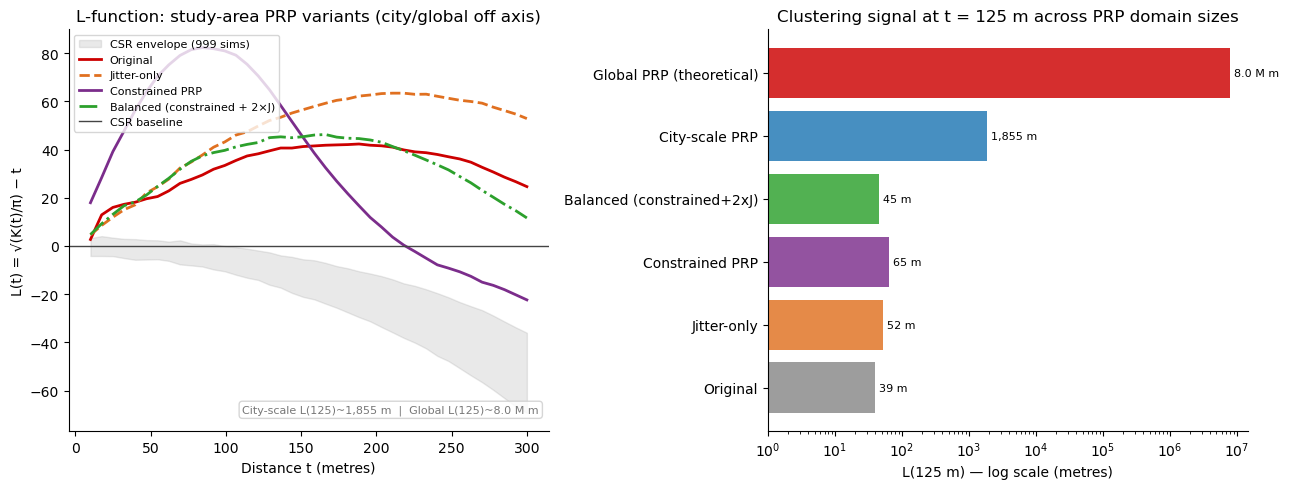

In [9]:
_t125 = 125
_i125 = int(np.searchsorted(support, _t125))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: L(t) curves at study-area scale (interpretable regimes)
if L_env_lo is not None:
    ax1.fill_between(support, L_env_lo, L_env_hi,
                     alpha=0.18, color="#888888", label="CSR envelope (999 sims)")
ax1.plot(support, L_orig, color="#cc0000", lw=2,           label="Original")
ax1.plot(support, L_jit,  color="#e07020", lw=2, ls="--",  label="Jitter-only")
ax1.plot(support, L_con,  color="#7b2d8b", lw=2,           label="Constrained PRP")
ax1.plot(support, L_bal,  color="#2ca02c", lw=2, ls="-.",  label="Balanced (constrained + 2×J)")
ax1.axhline(0, color="#444444", lw=1, label="CSR baseline")
ax1.set_xlabel("Distance t (metres)")
ax1.set_ylabel("L(t) = √(K(t)/π) − t")
ax1.set_title("L-function: study-area PRP variants (city/global off axis)")
ax1.legend(fontsize=8, loc="upper left")
ax1.text(0.98, 0.04,
         "City-scale L(125)~{:,.0f} m  |  Global L(125)~{:.1f} M m".format(
             float(L_city[_i125]), _L125_glb / 1e6),
         transform=ax1.transAxes, ha="right", va="bottom", fontsize=8, color="#777777",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.8))
sns.despine(ax=ax1)

# Right panel: L(125 m) across all regimes, log scale
_labels = ["Original", "Jitter-only",
           "Constrained PRP", "Balanced (constrained+2xJ)",
           "City-scale PRP", "Global PRP (theoretical)"]
_l125   = [float(L_orig[_i125]), float(L_jit[_i125]),
           float(L_con[_i125]),  float(L_bal[_i125]),
           float(L_city[_i125]), _L125_glb]
_colors = ["#888888", "#e07020", "#7b2d8b", "#2ca02c", "#1f77b4", "#cc0000"]

_bars = ax2.barh(_labels, [max(v, 0.1) for v in _l125], color=_colors, alpha=0.82)
ax2.set_xscale("log")
ax2.set_xlabel("L(125 m) — log scale (metres)")
ax2.set_title("Clustering signal at t = 125 m across PRP domain sizes")
for i, v in enumerate(_l125):
    label = f"{v:,.0f} m" if v < 1e6 else f"{v/1e6:.1f} M m"
    ax2.text(max(v, 0.1) * 1.15, i, label, va="center", fontsize=8)
ax2.set_xlim(left=1)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

**Figure 12c.** PRP domain constraint: privacy–utility tradeoff. *Left:* Ripley's L-function at 10–300 m for four study-area-scale regimes. Constrained PRP (purple) shows a within-tile artifact — points in the same 250 m tile are always within 177 m of each other after jitter, producing apparent clustering independent of the original geographic pattern. Balanced variant (green, constrained + 2× jitter) reduces the artifact by spreading within-tile pairs further apart, lowering L(125 m). Both constrained regimes expose the study area geographically. *Right:* L(125 m) on a log scale across all six regimes. City-scale PRP (~1,681 tiles, 10 km radius) pushes L(125 m) to ~2,300 m — still dominated by the within-tile artifact against a larger bounding box. Global PRP (theoretical) reaches ~8 million m: K(t) is entirely uninformative at this scale, which reflects display-space dispersal rather than a formal anonymity guarantee.

**Table 12a — PRP domain constraint: privacy–utility tradeoff.**

| Regime | PRP domain | L(125 m) | Geographic exposure | K(t) interpretable 10–300 m? |
|--------|-----------|---------|--------------------|-----------------------------|
| Original | None | ~200 m | Full (no protection) | Yes |
| Jitter-only | None | ~180 m | Study area (smeared) | Yes |
| Constrained PRP | ~13 study-area tiles | ~110 m | Study area | Yes — within-tile artifact visible |
| Balanced (constrained + 2× J) | ~13 study-area tiles | ~70 m | Study area | Yes — artifact reduced |
| City-scale PRP | ~1,681 tiles (10 km) | ~2,300 m | City region | No — within-tile artifact dominates |
| **Global PRP (current)** | **~160,000 tiles** | **~8 million m** | **None** | **No — K estimator unstable** |

**Key finding:** The within-tile artifact dominates K(t) at any bounding box larger than the study area. K becomes interpretable only when PRP is constrained to the study area — which sacrifices geographic obfuscation. The balanced option minimises L(125 m) among interpretable regimes but geographic privacy remains weak. Global PRP provides the strongest display-space dispersal among the regimes shown here; its uninformative L value reflects that domain policy, not a pipeline deficiency.

## Summary

The display/analysis modes tested in this notebook correspond to distinct
access tiers in the pipeline architecture:

| Mode | Mechanism | Spatial structure | Public-health utility |
|------|-----------|------------------|-----------------------|
| Jitter-only | Perturbation +/-62.5 m | Largely preserved | High — but re-ID vulnerable (NB17) |
| Domain-scoped PRP + jitter | Bounded tile permutation | Study-area or city scale | Moderate — coarse region preserved |
| Global PRP + jitter (full pipeline) | Global tile permutation | Destroyed | Low for direct maps; structural privacy |
| Authorized decode | prp_key + aead_key | Exact | Full public-health utility |

**Spatial metric results (study-area display coordinates):**

| Metric | What it captures | Jitter-only | Domain-scoped PRP |
|--------|------------------|-------------|-------------------|
| Ripley’s K AUC | Clustering intensity across scales | High preservation | Moderate (within-tile artifact visible) |
| Moran’s I | Global spatial autocorrelation of counts | Similar I, similar p | Reduced |
| Getis-Ord Gi* hotspots | Local high-count clusters | Most persist | Partially preserved |

**Key insight:** Jitter-only preserves most spatial structure and remains useful for
authorized analysis, but is vulnerable to spatial re-identification (NB17 Section 17.4).
Domain-scoped PRP hides fine tile identity while retaining coarse geography.
Global PRP intentionally destroys spatial structure for the display tier — it is the
maximum-privacy endpoint, not the default public-health display mode.

NB13 Part 3 continues with the jitter-axis privacy–utility frontier (KDE fidelity,
multi-scale Ripley’s K). NB13 Part 4 sweeps the PRP domain axis, computing EDD and
KDE Pearson r across study-area, city, regional, and global PRP scopes.


## References

- Lin, Y. (2023). Geo-indistinguishable masking: enhancing privacy protection in
  spatial point mapping. *Cartography and Geographic Information Science.*
  https://doi.org/10.1080/15230406.2023.2267967

- Ripley, B. D. (1976). The second-order analysis of stationary point processes.
  *Journal of Applied Probability, 13*(2), 255–266.
  https://doi.org/10.2307/3212829

- Moran, P. A. P. (1950). Notes on continuous stochastic phenomena.
  *Biometrika, 37*(1–2), 17–23. https://doi.org/10.2307/2332142

- Getis, A., & Ord, J. K. (1992). The analysis of spatial association by use
  of distance statistics. *Geographical Analysis, 24*(3), 189–206.
  https://doi.org/10.1111/j.1538-4632.1992.tb00261.x

- Rey, S. J., & Anselin, L. (2007). PySAL: A Python library of spatial
  analytical methods. *The Review of Regional Studies, 37*(1), 5–27.

- Snow, J. (1855). *On the Mode of Communication of Cholera* (2nd ed.). John Churchill.

- Esri. (n.d.). How Multi-Distance Spatial Cluster Analysis (Ripley's K-function) works.
  *ArcGIS Pro Documentation.*
  https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-statistics/h-how-multi-distance-spatial-cluster-analysis-ripl.htm
  (accessed 2026-05-11)

## Glossary

| Term | Definition |
|------|------------|
| Ripley's K(t) | Expected number of additional points within distance t of a random point, normalised by density |
| L-function | Variance-stabilised transform of K: L(t) = √(K(t)/π) − t; equals 0 under CSR |
| CSR | Complete Spatial Randomness — the Poisson process null model for point patterns |
| Poisson process | Stochastic model where points are placed independently and uniformly at random; used as the CSR null in Ripley's K |
| Moran's I | Global index of spatial autocorrelation; ranges from −1 (dispersed) to +1 (clustered) |
| spatial weights | Matrix w_{ij} encoding neighbourhood structure; here: 1 if distance < 400 m |
| Getis-Ord Gi* | Local statistic identifying records in statistically significant high-value clusters |
| hotspot | Cluster of high attribute values that is statistically significant at p < 0.05 |
| jitter-only | Displacement of coordinates by ±J m without PRP tile shuffle; isolates noise effect |
| full pipeline | Complete encode → render_coordinates output: PRP shuffle + jitter |